# Chapter 1 — Exploratory Data Analysis
### Reproduction & Theoretical Deep-Dive — *Practical Statistics for Data Scientists* (Bruce, Bruce & Gedeck, 2nd ed.)

This notebook reproduces the core code examples of Chapter 1 and adds a
theoretical explanation for every concept covered. The goal is not just to
run the code, but to understand **why** each statistic or visualization is
used and what it tells us about a dataset.

**Chapter roadmap:**
1. Estimates of Location
2. Estimates of Variability
3. Exploring the Data Distribution (percentiles, boxplots, histograms, density)
4. Exploring Binary and Categorical Data
5. Correlation
6. Exploring Two or More Variables


In [1]:
%matplotlib inline
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import trim_mean
from statsmodels import robust
import wquantiles

import matplotlib.pylab as plt
import seaborn as sns

sns.set_style('whitegrid')

DATA = Path('data')
STATE_CSV = DATA / 'state.csv'
DFW_AIRLINE_CSV = DATA / 'dfw_airline.csv'
SP500_SECTORS_CSV = DATA / 'sp500_sectors.csv'
SP500_DATA_CSV = DATA / 'sp500_data.csv.gz'
KC_TAX_CSV = DATA / 'kc_tax.csv.gz'
LC_LOANS_CSV = DATA / 'lc_loans.csv'
AIRLINE_STATS_CSV = DATA / 'airline_stats.csv'


## 1. Estimates of Location

**Theory.** A location estimate answers "where is the data centered?".
- **Mean** — the arithmetic average. Sensitive to outliers because every value
  is weighted equally, including extreme ones.
- **Trimmed mean** — drop the top/bottom *p%* of sorted values, then average
  the rest. This removes the influence of outliers while still using most of
  the data (more robust than the mean, more efficient than the median).
- **Median** — the middle value of the sorted data (50th percentile). It is
  the most *robust* location estimate: a single extreme outlier cannot move it
  much, since it only depends on rank, not magnitude.
- **Weighted mean / weighted median** — used when observations should not
  count equally, e.g. states with tiny populations shouldn't influence a
  national murder-rate average as much as California.

We use the `state.csv` dataset (US state population and murder rate per
100,000 people) to illustrate this.


In [2]:
state = pd.read_csv(STATE_CSV)
state.head(8)


,State,Population,Murder.Rate,Abbreviation
0,Alabama,4779736,5.7,AL
1,Alaska,710231,5.6,AK
2,Arizona,6392017,4.7,AZ
3,Arkansas,2915918,5.6,AR
4,California,37253956,4.4,CA
5,Colorado,5029196,2.8,CO
6,Connecticut,3574097,2.4,CT
7,Delaware,897934,5.8,DE


In [3]:
mean_pop = state['Population'].mean()
trimmed_mean_pop = trim_mean(state['Population'], 0.1)  # drop 10% each tail
median_pop = state['Population'].median()

print(f"Mean population:         {mean_pop:,.0f}")
print(f"10%% trimmed mean:        {trimmed_mean_pop:,.0f}")
print(f"Median population:       {median_pop:,.0f}")


Mean population:         6,162,876
10%% trimmed mean:        4,783,697
Median population:       4,436,370


In [4]:
# Weighted mean / median for Murder Rate, weighted by state Population.
# States like California should influence the national picture more than Wyoming.
weighted_mean_murder = np.average(state['Murder.Rate'], weights=state['Population'])
weighted_median_murder = wquantiles.median(state['Murder.Rate'], weights=state['Population'])

print(f"Unweighted mean murder rate:   {state['Murder.Rate'].mean():.2f}")
print(f"Population-weighted mean:      {weighted_mean_murder:.2f}")
print(f"Population-weighted median:    {weighted_median_murder:.2f}")


Unweighted mean murder rate:   4.07
Population-weighted mean:      4.45
Population-weighted median:    4.40


**Reading the output.** The trimmed mean sits close to the median and
below the raw mean — a sign that population is right-skewed (a few very large
states, like California and Texas, pull the mean upward). The population-
weighted murder-rate mean differs from the unweighted mean because it gives
proportionally more say to populous states.


## 2. Estimates of Variability

**Theory.** Location alone isn't enough — two datasets can share the same
mean but have very different spread. Variability measures answer "how spread
out is the data?".
- **Standard deviation / variance** — average squared deviation from the
  mean, then (for std. dev.) square-rooted back to original units. Sensitive
  to outliers (because of squaring).
- **Mean absolute deviation (MAD)** — average of absolute deviations from the
  median. More robust than std. dev.
- **Median absolute deviation from the median (robust MAD)** — the median of
  the absolute deviations from the median, typically rescaled by a constant
  (~1.4826) so it estimates the standard deviation consistently for normal
  data. This is the most outlier-resistant spread measure here.
- **Range and Interquartile Range (IQR)** — range is max − min (very
  sensitive to outliers); IQR = 75th percentile − 25th percentile, robust and
  widely used (it defines boxplot whiskers).


In [5]:
std_pop = state['Population'].std()
robust_mad_pop = robust.scale.mad(state['Population'])
iqr_pop = state['Population'].quantile(0.75) - state['Population'].quantile(0.25)

print(f"Standard deviation of population: {std_pop:,.0f}")
print(f"Robust MAD of population:         {robust_mad_pop:,.0f}")
print(f"IQR of population:                {iqr_pop:,.0f}")


Standard deviation of population: 6,848,235
Robust MAD of population:         3,849,876
IQR of population:                4,847,308


**Reading the output.** The robust MAD is much smaller than the
standard deviation — the std. dev. is inflated by a handful of huge states
(outliers), while the MAD isn't. This is exactly why robust statistics matter
in exploratory analysis: they describe the "typical" spread without being
dominated by a few extreme points.


### 2.1 Percentiles and Boxplots

**Theory.** A percentile is the value below which a given percentage of the
data falls (median = 50th percentile). A **boxplot** visualizes the
five-number summary: minimum (within 1.5×IQR), Q1, median, Q3, maximum
(within 1.5×IQR) — points beyond the whiskers are plotted individually as
potential outliers. Boxplots are ideal for quickly comparing distributions
across several groups.


In [6]:
percentiles = state['Murder.Rate'].quantile([0.05, 0.25, 0.5, 0.75, 0.95])
print(percentiles)


0.05    1.600
0.25    2.425
0.50    4.000
0.75    5.550
0.95    6.510
Name: Murder.Rate, dtype: float64


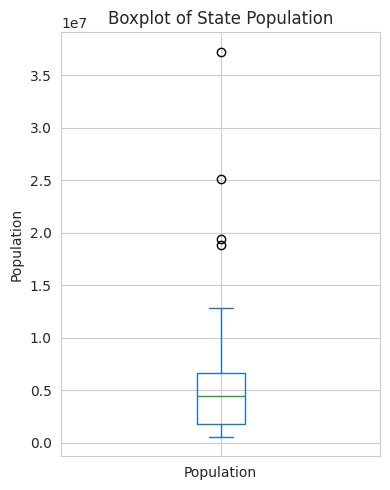

In [7]:
fig, ax = plt.subplots(figsize=(4, 5))
ax = state['Population'].plot.box(ax=ax)
ax.set_ylabel('Population')
ax.set_title('Boxplot of State Population')
plt.tight_layout()
plt.savefig('outputs/boxplot_population.png', dpi=110)
plt.show()


**Reading the output.** The boxplot shows most states clustered near the
bottom of the axis, with several points marked above the upper whisker —
those are the high-population outlier states (e.g., California, Texas). The
box itself (Q1–Q3) represents the middle 50% of states.


### 2.2 Frequency Table and Histograms

**Theory.** A frequency table bins continuous data into intervals and counts
how many observations fall in each — this is the tabular version of a
histogram. Histograms visualize the *shape* of a distribution: is it
symmetric, skewed, uni-/multi-modal? Unlike a boxplot, a histogram shows the
full distribution shape, not just a five-number summary.


In [8]:
binned = pd.cut(state['Population'], bins=10)
freq_table = binned.value_counts().sort_index()
freq_table


Population
(526935.67, 4232659.0]      24
(4232659.0, 7901692.0]      14
(7901692.0, 11570725.0]      6
(11570725.0, 15239758.0]     2
(15239758.0, 18908791.0]     1
(18908791.0, 22577824.0]     1
(22577824.0, 26246857.0]     1
(26246857.0, 29915890.0]     0
(29915890.0, 33584923.0]     0
(33584923.0, 37253956.0]     1
Name: count, dtype: int64

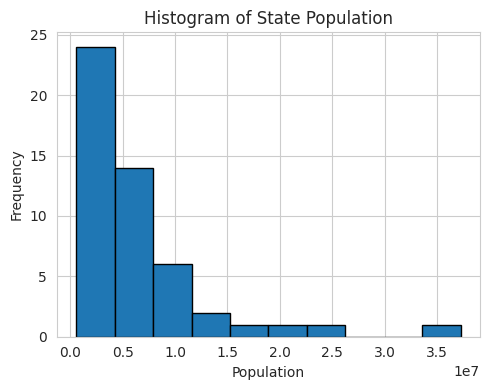

In [9]:
fig, ax = plt.subplots(figsize=(5, 4))
ax = state['Population'].plot.hist(ax=ax, bins=10, edgecolor='black')
ax.set_xlabel('Population')
ax.set_title('Histogram of State Population')
plt.tight_layout()
plt.savefig('outputs/hist_population.png', dpi=110)
plt.show()


**Reading the output.** The histogram confirms right-skew: most states
sit in the lower population bins, with a long tail of a few very populous
states. This matches what the trimmed-mean-vs-mean gap suggested earlier.


### 2.3 Density Estimates

**Theory.** A **Kernel Density Estimate (KDE)** is a smoothed, continuous
version of a histogram — instead of hard bins, each data point contributes a
small "bump" (kernel), and these bumps are summed to form a smooth curve.
KDEs avoid the arbitrary bin-edge artifacts of histograms and are useful for
estimating the underlying probability density.


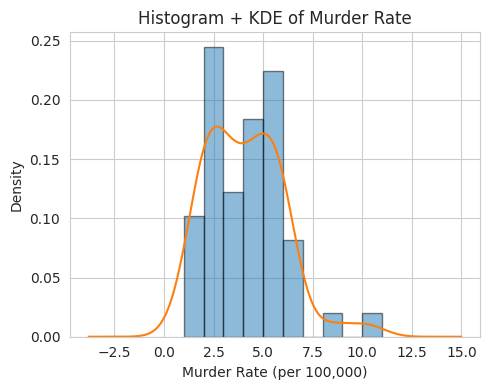

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
state['Murder.Rate'].plot.hist(ax=ax, density=True, bins=range(1, 12), edgecolor='black', alpha=0.5)
state['Murder.Rate'].plot.density(ax=ax)
ax.set_xlabel('Murder Rate (per 100,000)')
ax.set_title('Histogram + KDE of Murder Rate')
plt.tight_layout()
plt.savefig('outputs/kde_murder_rate.png', dpi=110)
plt.show()


**Reading the output.** The KDE curve traces a smooth, roughly
bell-shaped peak that overlays the jagged histogram — showing that murder
rate across states is fairly unimodal and only mildly skewed, unlike the
heavily skewed population variable.


## 3. Exploring Binary and Categorical Data

**Theory.** Numeric summaries (mean, std. dev.) don't apply to categories.
Instead we use:
- **Bar charts** — frequency/proportion of each category, bars have gaps
  (categories are discrete and unordered) — different from histograms, whose
  bars touch (continuous bins).
- Categorical exploration is often the first step before any classification
  task, since it reveals class imbalance.

We use `dfw_airline.csv`, which holds the percentage of Dallas/Fort Worth
flight delays by cause.


In [11]:
dfw = pd.read_csv(DFW_AIRLINE_CSV)
dfw


,Carrier,ATC,Weather,Security,Inbound
0,64263.16,84856.5,11235.42,343.15,118427.82


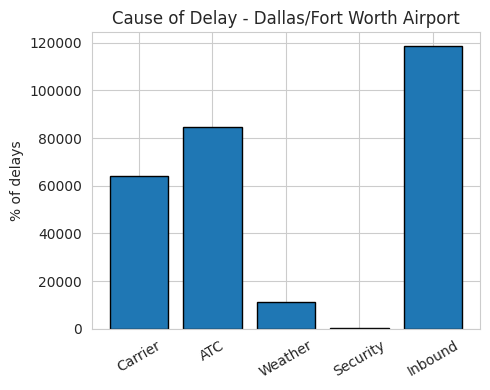

In [12]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(dfw.columns, dfw.iloc[0], edgecolor='black')
ax.set_ylabel('% of delays')
ax.set_title('Cause of Delay - Dallas/Fort Worth Airport')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('outputs/bar_delay_causes.png', dpi=110)
plt.show()


**Reading the output.** Carrier-related and aviation-system delays
dominate the chart — this immediately tells an analyst where to focus root-
cause investigation, something a plain average couldn't reveal.


## 4. Correlation

**Theory.** Correlation measures the strength and direction of a **linear**
relationship between two numeric variables, ranging from −1 (perfect
negative) to +1 (perfect positive), with 0 meaning no linear relationship.
The most common measure is the **Pearson correlation coefficient**. Important
caveat: correlation only captures *linear* association — two variables can be
strongly related non-linearly and still show near-zero Pearson correlation.
A **correlation matrix / heatmap** lets us scan many variable pairs at once.


In [13]:
sp500_sectors = pd.read_csv(SP500_SECTORS_CSV)
sp500_data = pd.read_csv(SP500_DATA_CSV, index_col=0)

# Focus on a handful of telecom / tech tickers for a compact, readable matrix
telecom_symbols = sp500_sectors[sp500_sectors['sector'] == 'telecommunications_services']['symbol']
telecom = sp500_data.loc[:, sp500_data.columns.isin(telecom_symbols)]
telecom = telecom[telecom.columns[telecom.notna().sum() > 0]]
telecom.corr()


,T,CTL,FTR,VZ,LVLT
T,1.000000,0.405853,0.283279,0.617035,0.061545
CTL,0.405853,1.000000,0.377644,0.385752,0.054534
FTR,0.283279,0.377644,1.000000,0.289295,0.067313
VZ,0.617035,0.385752,0.289295,1.000000,0.045919
LVLT,0.061545,0.054534,0.067313,0.045919,1.000000


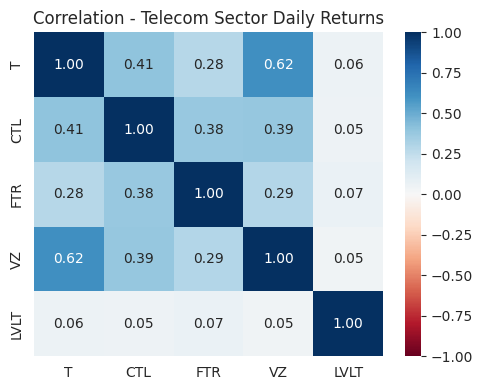

In [14]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(telecom.corr(), vmin=-1, vmax=1, cmap='RdBu', annot=True, fmt='.2f', ax=ax)
ax.set_title('Correlation - Telecom Sector Daily Returns')
plt.tight_layout()
plt.savefig('outputs/corr_heatmap_telecom.png', dpi=110)
plt.show()


**Reading the output.** Stocks within the same sector tend to move
together (positive correlation), which is expected — they share economic
exposure (regulation, consumer spending on telecom services, etc.). This kind
of matrix is a standard first step before building a portfolio or a
regression model with multiple predictors, to spot multicollinearity early.


### 4.1 Scatterplots

**Theory.** A scatterplot is the most direct way to *see* the relationship
between two numeric variables — each point is one observation. It reveals
things a correlation number alone can hide: nonlinearity, clusters, and
outliers.


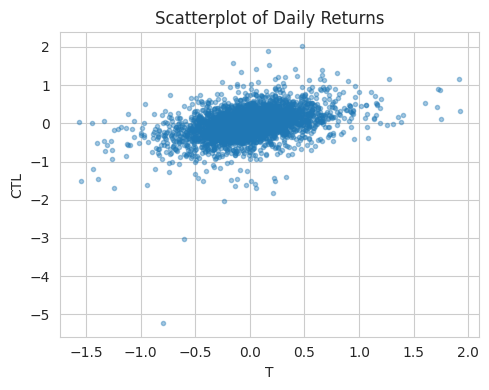

In [15]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(telecom.iloc[:, 0], telecom.iloc[:, 1], marker='.', alpha=0.4)
ax.set_xlabel(telecom.columns[0])
ax.set_ylabel(telecom.columns[1])
ax.set_title('Scatterplot of Daily Returns')
plt.tight_layout()
plt.savefig('outputs/scatter_telecom.png', dpi=110)
plt.show()


**Reading the output.** Points cluster along a rough diagonal — visual
confirmation of the positive correlation computed above, and the spread
around the diagonal shows how imperfect that linear relationship really is.


## 5. Exploring Two or More Variables

**Theory.** With large datasets, a plain scatterplot becomes an unreadable
"blob" of overplotted points. We need aggregation-based visuals instead:
- **Hexagonal binning** — like a 2D histogram; the plane is divided into
  hexagonal cells, and each cell is shaded by the count of points inside it.
- **Contour plots** — draw lines of equal density on top of a 2D density
  estimate, like a topographic map.
- **Two categorical variables** — summarized with a contingency
  (cross-tabulation) table.
- **Categorical + numeric** — often shown with grouped boxplots or violin
  plots, comparing a numeric distribution across category levels.
- **Multiple variables (facets)** — small multiples ("trellis"/facet grids)
  repeat the same chart type across subsets, adding a further categorical
  dimension without cluttering a single plot.


In [16]:
kc_tax = pd.read_csv(KC_TAX_CSV)
# Filter to a reasonable range to remove extreme recording errors, as the book does
kc_tax0 = kc_tax.loc[(kc_tax['TaxAssessedValue'] < 750000) &
                      (kc_tax['SqFtTotLiving'] > 100) &
                      (kc_tax['SqFtTotLiving'] < 3500), :]
print(f"Rows before filter: {len(kc_tax):,} -> after filter: {len(kc_tax0):,}")


Rows before filter: 498,249 -> after filter: 432,693


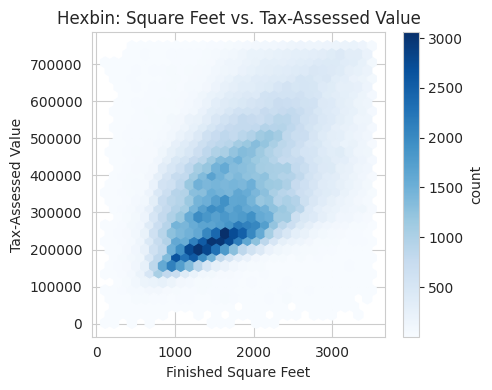

In [17]:
fig, ax = plt.subplots(figsize=(5, 4))
hb = ax.hexbin(kc_tax0['SqFtTotLiving'], kc_tax0['TaxAssessedValue'],
                gridsize=30, cmap='Blues', mincnt=1)
ax.set_xlabel('Finished Square Feet')
ax.set_ylabel('Tax-Assessed Value')
ax.set_title('Hexbin: Square Feet vs. Tax-Assessed Value')
fig.colorbar(hb, ax=ax, label='count')
plt.tight_layout()
plt.savefig('outputs/hexbin_kc_tax.png', dpi=110)
plt.show()


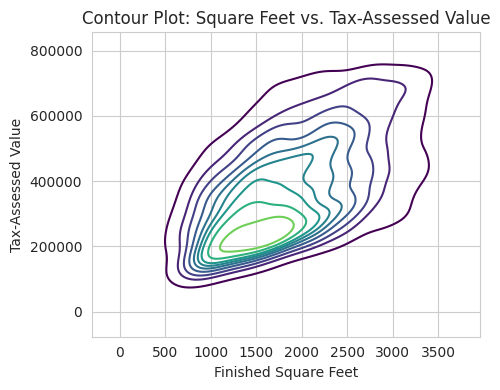

In [18]:
# KDE contour estimation is expensive on ~140K rows; a random subsample
# gives the same density shape at a fraction of the compute cost.
kc_tax0_sample = kc_tax0.sample(5000, random_state=1)

fig, ax = plt.subplots(figsize=(5, 4))
sns.kdeplot(x=kc_tax0_sample['SqFtTotLiving'], y=kc_tax0_sample['TaxAssessedValue'],
            ax=ax, fill=False, cmap='viridis')
ax.set_xlabel('Finished Square Feet')
ax.set_ylabel('Tax-Assessed Value')
ax.set_title('Contour Plot: Square Feet vs. Tax-Assessed Value')
plt.tight_layout()
plt.savefig('outputs/contour_kc_tax.png', dpi=110)
plt.show()


**Reading the output.** Both plots reveal a dense, roughly linear
relationship between house size and assessed value, along with the shape of
that density — information that would be completely hidden by
overplotted points in a plain scatterplot of ~140K rows.


### 5.1 Two Categorical Variables

We cross-tabulate loan `grade` against loan `status` from `lc_loans.csv`.


In [19]:
lc_loans = pd.read_csv(LC_LOANS_CSV)
crosstab = lc_loans.pivot_table(index='grade', columns='status', aggfunc=len, margins=True, fill_value=0)
crosstab


status,Charged Off,Current,Fully Paid,Late,All
grade,,,,,
A,1562,50051,20408,469,72490
B,5302,93852,31160,2056,132370
C,6023,88928,23147,2777,120875
D,5007,53281,13681,2308,74277
E,2842,24639,5949,1374,34804
F,1526,8444,2328,606,12904
G,409,1990,643,199,3241
All,22671,321185,97316,9789,450961


In [20]:
# Convert to row-wise percentages: what fraction of each grade falls into each status?
df = crosstab.copy().loc['A':'G', :]
df = df.div(df['All'], axis=0)
df = df.drop(columns='All')
df


status,Charged Off,Current,Fully Paid,Late
grade,,,,
A,0.021548,0.690454,0.281528,0.006470
B,0.040054,0.709013,0.235401,0.015532
C,0.049828,0.735702,0.191495,0.022974
D,0.067410,0.717328,0.184189,0.031073
E,0.081657,0.707936,0.170929,0.039478
F,0.118258,0.654371,0.180409,0.046962
G,0.126196,0.614008,0.198396,0.061401


**Reading the output.** Lower loan grades (closer to G) show a higher
proportion of "Charged Off" / "Default" outcomes than higher grades (A/B) —
exactly what a credit-risk grading system should show, and a useful sanity
check before any classification modeling.


### 5.2 Categorical and Numeric Data

We compare flight-delay time (numeric) across airline carriers (categorical)
using `airline_stats.csv`, with a boxplot per group.


In [21]:
airline_stats = pd.read_csv(AIRLINE_STATS_CSV)
airline_stats.head()


,pct_carrier_delay,pct_atc_delay,pct_weather_delay,airline
0,8.153226,1.971774,0.762097,American
1,5.959924,3.706107,1.585878,American
2,7.157270,2.706231,2.026706,American
3,12.100000,11.033333,0.000000,American
4,7.333333,3.365591,1.774194,American


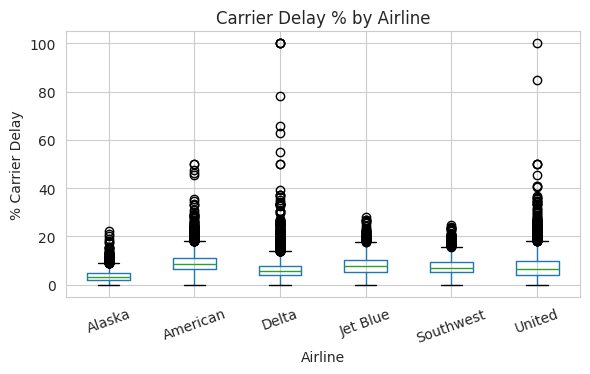

In [22]:
fig, ax = plt.subplots(figsize=(6, 4))
airline_stats.boxplot(by='airline', column='pct_carrier_delay', ax=ax)
ax.set_xlabel('Airline')
ax.set_ylabel('% Carrier Delay')
plt.suptitle('')
ax.set_title('Carrier Delay % by Airline')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('outputs/boxplot_delay_by_airline.png', dpi=110)
plt.show()


**Reading the output.** Grouped boxplots let us compare not just the
average delay per airline, but also the spread and outliers for each —
information that a single bar chart of means would flatten away.


### 5.3 Visualizing Multiple Variables (Facets)

We extend the hexbin plot from §5 by faceting it across a further
categorical dimension — number of bedrooms — to see how the
size-vs-value relationship shifts across property types.


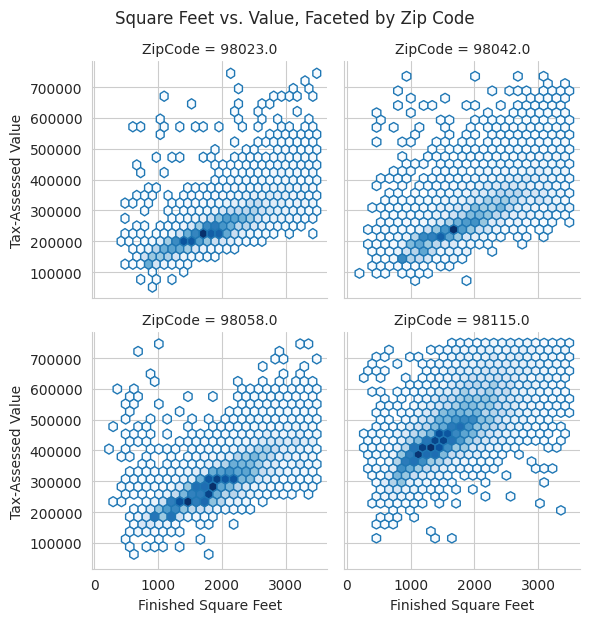

In [23]:
kc_tax0_facet = kc_tax0.copy()
zip_sample = kc_tax0_facet['ZipCode'].value_counts().head(4).index  # 4 busiest zip codes, for readability
kc_tax0_facet = kc_tax0_facet[kc_tax0_facet['ZipCode'].isin(zip_sample)]

g = sns.FacetGrid(kc_tax0_facet, col='ZipCode', col_wrap=2, height=3)
g.map(plt.hexbin, 'SqFtTotLiving', 'TaxAssessedValue', gridsize=25, cmap='Blues', mincnt=1)
g.set_axis_labels('Finished Square Feet', 'Tax-Assessed Value')
g.fig.suptitle('Square Feet vs. Value, Faceted by Zip Code', y=1.03)
g.savefig('outputs/facet_kc_tax_by_zip.png', dpi=110)
plt.show()


**Reading the output.** Faceting shows that the size-vs-value
relationship (slope, spread) differs by neighborhood — some zip codes have a
steeper price-per-square-foot trend than others, a pattern completely
invisible in the single aggregated hexbin plot from §5.


## Summary

| Concept | What it tells you | Robust to outliers? |
|---|---|---|
| Mean | Center of the data | No |
| Trimmed mean | Center, outlier-resistant | Mostly |
| Median | Center (rank-based) | Yes |
| Std. deviation | Spread | No |
| Robust MAD | Spread | Yes |
| IQR / boxplot | Spread + outlier flags | Yes |
| Histogram / KDE | Full distribution shape | — |
| Bar chart | Category frequencies | — |
| Correlation / heatmap | Linear relationship strength | No |
| Hexbin / contour | 2D density for large N | — |
| Cross-tab | Relationship between two categoricals | — |
| Grouped boxplot | Numeric distribution per category | — |
| Facets | Add a 3rd (categorical) dimension to any plot | — |

The overarching lesson of Chapter 1: **always look at both a robust and a
non-robust estimate together** — the *gap* between them (e.g., mean vs.
median, std. dev. vs. MAD) is itself diagnostic of skew and outliers, before
any modeling begins.
